In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [25]:
df = pd.read_csv("../../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [26]:
df.shape

(7043, 21)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [28]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [29]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [30]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [31]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [32]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

C:\Users\HP\AppData\Local\Temp\ipykernel_3212\575980950.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

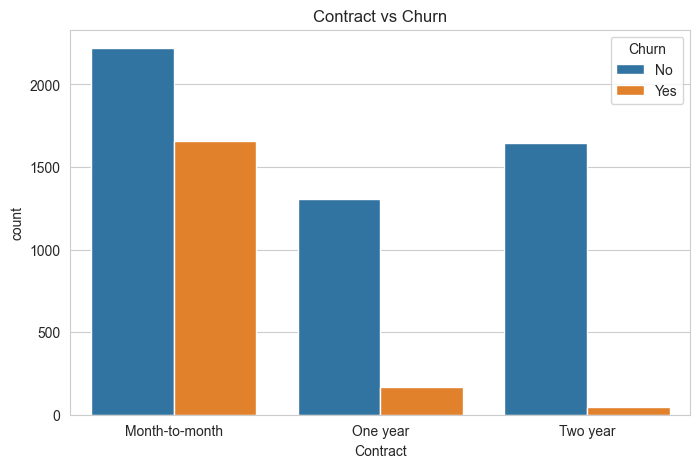

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract vs Churn")
plt.show()

In [34]:
# Observation:
# Month-to-month customers have higher churn.
# Two-year contract customers have lower churn.

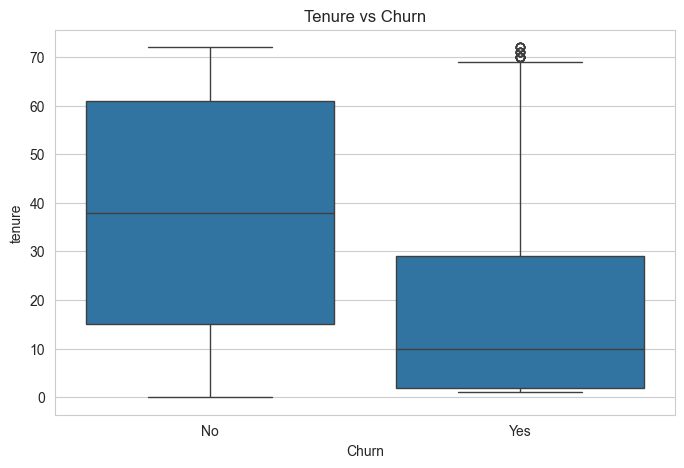

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.show()

In [36]:
# Observation:
# Low tenure customers churn more.

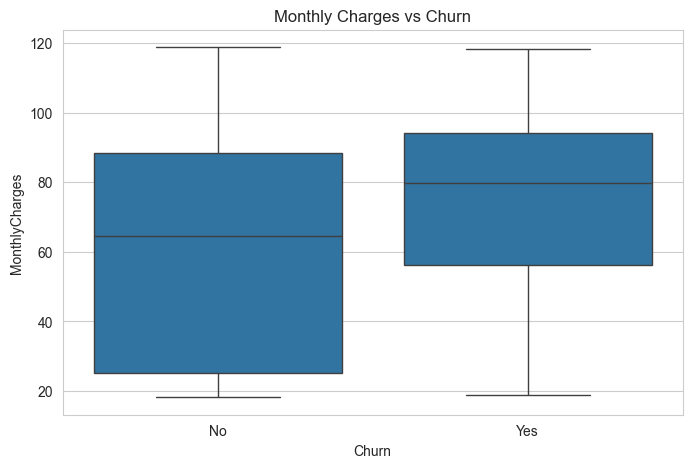

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

In [38]:
# Observation:
# Higher monthly charges increase churn.

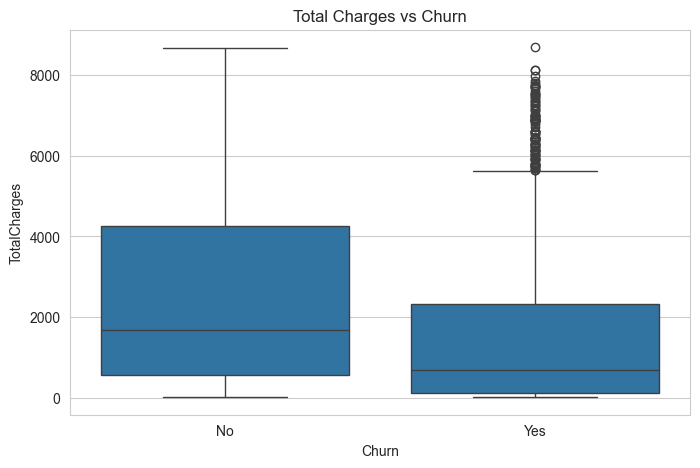

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")
plt.show()

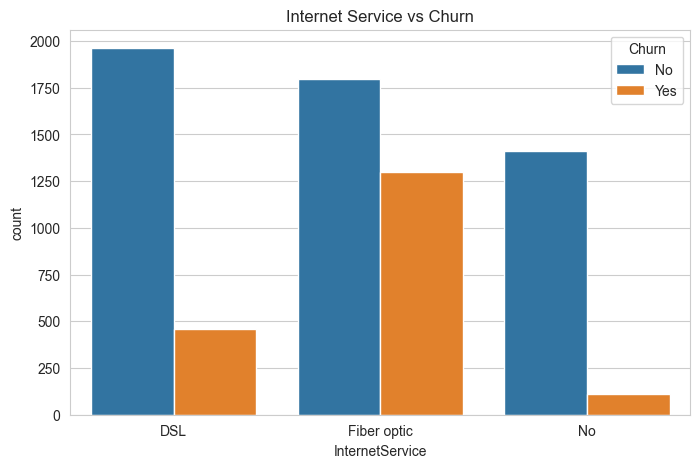

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")
plt.show()

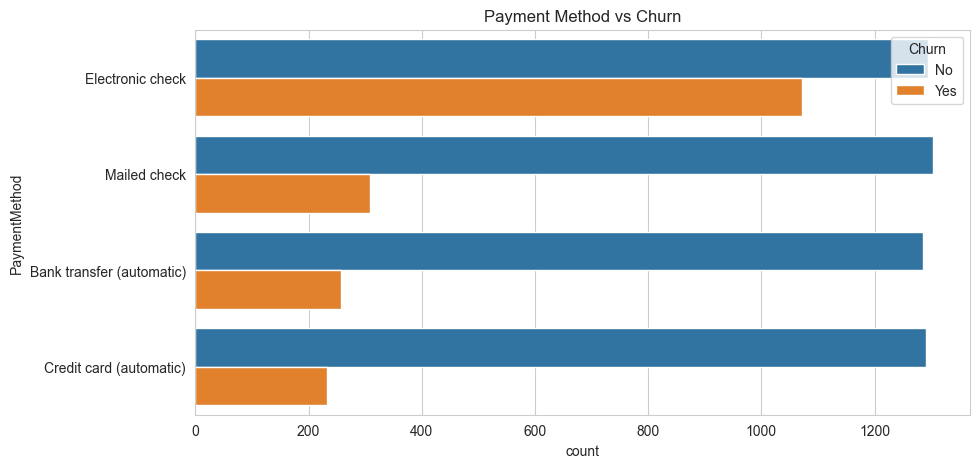

In [41]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y="PaymentMethod",
    hue="Churn"
)

plt.title("Payment Method vs Churn")
plt.show()

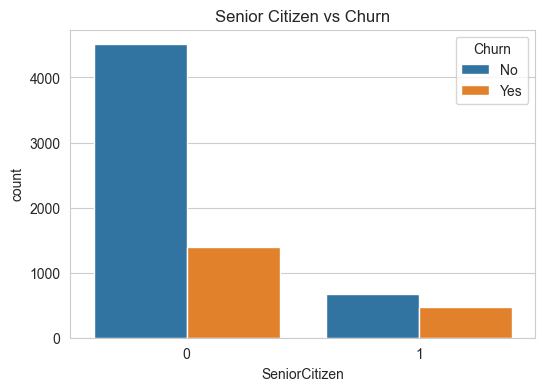

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Senior Citizen vs Churn")
plt.show()

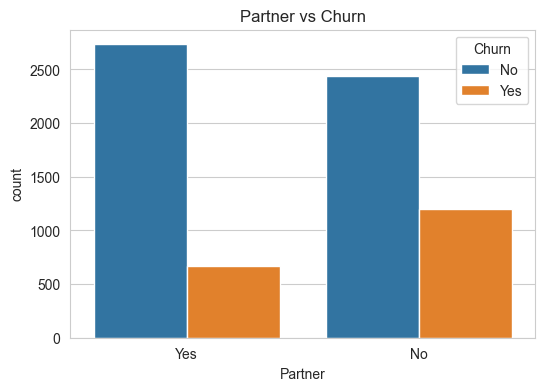

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)

plt.title("Partner vs Churn")
plt.show()

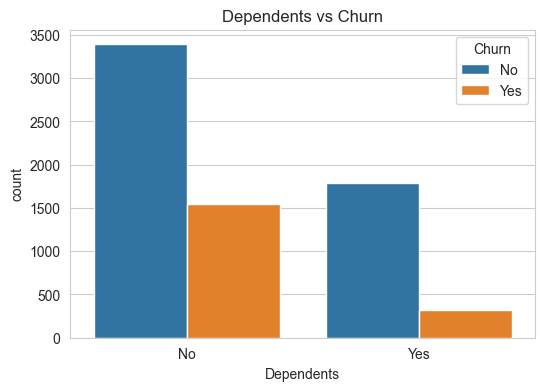

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)

plt.title("Dependents vs Churn")
plt.show()

In [45]:
df.groupby("Churn")[["tenure","MonthlyCharges","TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2555.344141
Yes,17.979133,74.441332,1531.796094


In [46]:
df.groupby(
    ["Contract","Churn"]
).agg({
    "tenure":"mean",
    "MonthlyCharges":"mean",
    "TotalCharges":"mean"
})

tenure  MonthlyCharges  TotalCharges
Contract       Churn                                         
Month-to-month No     21.033333       61.462635   1521.927590
               Yes    14.016918       73.019396   1164.460574
One year       No     41.674063       62.508148   2903.569908
               Yes    44.963855       85.050904   4066.212048
Two year       No     56.602914       60.012477   3678.986103
               Yes    61.270833       86.777083   5432.363542